<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/main/MOD-2/exam-examples/02/exercise_solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

The code below read data from data.csv, saving the input features in the array X and the binary outcome in the array y. Then it uses a "not optima" strategy to identify candidates casual features. The procedure includes several logical mistakes. Correct them and write a procedure that uses the estimated values of the coefficients of a logistic model to identify features that are relevant for predicting the outcome. Motivate your decisions.

NOTE: the class LogisticRegression of sklearn does not include a method to estimate the uncertainty of the coefficients. To not complicate the exercise too much, write a procedure that considers a feature as relevant for the outcome if the corresponding coefficient is higher than a threshold (so without considering the uncertainity).

Best parameters: {'model__max_iter': 1000}
Final model roc_auc: 0.8531931651958657
Index of important features: [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 51 52 53 54 55 56 57]


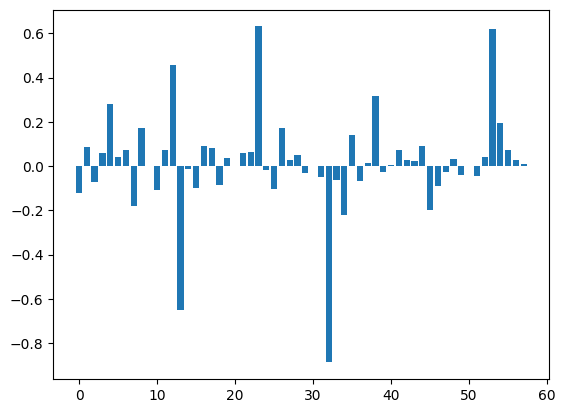

In [10]:
df = pd.read_csv("data.csv")
X = df.drop(columns=["target"]).to_numpy()
y = df["target"].to_numpy()

pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ("model", LogisticRegression(
            solver="saga",
            penalty='l1',
            random_state=RANDOM_STATE,
        )),

    ]
)
param_grid = {
    "model__max_iter": [1000, 5000, 10000],
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

# train-test split -->
grid_search.fit(X, y)
print("Best parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X)
y_proba = best_model.predict_proba(X)[:, 1]
print("Final model roc_auc:", roc_auc_score(y, y_proba))


coef = best_model.named_steps["model"].coef_.flatten()
f = plt.figure()
ax = f.add_subplot(1,1,1)
ax.bar(np.arange(len(coef)), coef)

threshold = 1e-3
inds = np.abs(coef) > threshold
print('Index of important features:', np.where(inds)[0])

Best parameters: {'model__C': np.float64(0.0657933224657568)}
Final model roc_auc: 0.8160061760164693
Index of important features: [ 0 13 23 32 38 53]


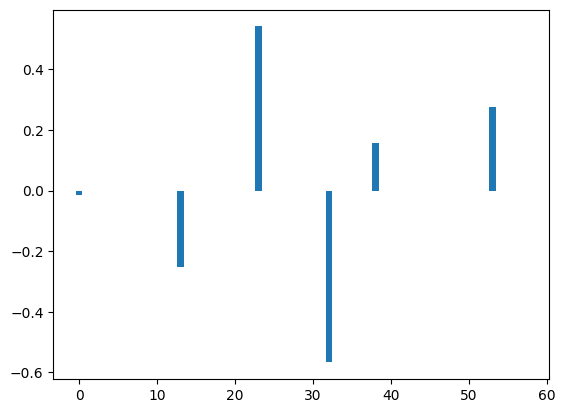

In [11]:
df = pd.read_csv("data.csv")
X = df.drop(columns=["target"]).to_numpy()
y = df["target"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            solver="saga",
            penalty="l1",
            max_iter=10000,
            random_state=RANDOM_STATE,
        )),
    ]
)
param_grid = {
    "model__C": np.logspace(-3, 2, 12),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]
print("Final model roc_auc:", roc_auc_score(y_test, y_proba))


coef = best_model.named_steps["model"].coef_.flatten()
f = plt.figure()
ax = f.add_subplot(1,1,1)
ax.bar(np.arange(len(coef)), coef)

threshold = 1e-8
inds = np.abs(coef) > threshold
print('Index of important features:', np.where(inds)[0])